<a href="https://colab.research.google.com/github/Prathamesh-kadam/GNN-Model/blob/main/Branch_spectral_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 22.9 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np

# LOAD DATA
df = pd.read_csv('csp_zheng.dat', sep=r'\s+', comment='#', header=None)

print("=== FULL DATA SHAPE ===")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print()

print("=== FIRST 10 ROWS (ALL COLUMNS) ===")
print(df.head(10))
print()

print("=== KEY ASTROPHYSICS COLUMNS ===")
print("Col 1: MB (magnitudes)")
print("Col 3: vSiII raw (before ×10)")
print("Col 5: pEW5972 (Å)")
print("Col 7: pEW6355 (Å)")
print()

# MOST IMPORTANT COLUMNS FOR OUR PLOTS
print("=== CRITICAL COLUMNS FOR PLOTTING ===")
print("\nColumn 3 (vSiII raw):")
print(f"  Min: {df.iloc[:,2].min():.3f}, Max: {df.iloc[:,2].max():.3f}")
print(f"  NaN count: {df.iloc[:,2].isna().sum()}, Inf count: {np.isinf(df.iloc[:,2]).sum()}")

print("\nColumn 5 (pEW5972):")
print(f"  Min: {df.iloc[:,4].min():.1f}, Max: {df.iloc[:,4].max():.1f}")

print("\nColumn 7 (pEW6355):")
print(f"  Min: {df.iloc[:,6].min():.1f}, Max: {df.iloc[:,6].max():.1f}")

print("\n=== FIRST 10 ROWS - JUST KEY COLUMNS ===")
key_cols = pd.DataFrame({
    'vSiII_raw': df.iloc[:,2],
    'pEW5972': df.iloc[:,4],
    'pEW6355': df.iloc[:,6]
})
print(key_cols.head(10))

print("\n=== DATA CLEANING STATS ===")
finite_all = np.isfinite(df.iloc[:,[2,4,6]]).all(axis=1)
print(f"Rows with finite vSiII+pEW: {finite_all.sum()}/{len(df)}")


=== FULL DATA SHAPE ===
Rows: 133, Columns: 9

=== FIRST 10 ROWS (ALL COLUMNS) ===
          0       1      2       3      4       5       6        7       8
0  SN2008hu -19.043  0.110  12.355  0.285  15.860   4.675  126.993   9.450
1  ASAS15bm -19.566  0.135  10.615  0.234   9.740   2.585   72.255   4.864
2   SN2005M -19.614  0.113   9.186  0.426   7.416   3.716   47.462   4.470
3  SN2008fr -19.351  0.119  10.073  0.422  19.343   3.565   93.275   6.319
4  SN2007ba -18.661  0.096  10.778  0.247  49.068   2.791   94.939   2.995
5    PTF14w -18.803  0.133  12.217  0.334  36.998   2.330  123.984   3.431
6  SN2008hv -19.124  0.167  10.798  0.359  21.291   2.094   96.728   3.255
7  SN2005hc -19.465  0.102  10.309  0.561  12.645  13.467  101.497  16.467
8  CSP15aae -17.923  0.154  11.489  0.364  56.793   2.807  151.522   3.666
9  SN2013gy -19.392  0.176  10.170  0.296  28.858   4.226  114.145   4.339

=== KEY ASTROPHYSICS COLUMNS ===
Col 1: MB (magnitudes)
Col 3: vSiII raw (before ×10)
Col 5

In [ ]:
import pandas as pd
import numpy as np

# LOAD DATA (no header)
df = pd.read_csv('csp_zheng.dat', sep=r'\s+', comment='#', header=None)

print("=== DATAFILE INFO ===")
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print("\n=== ALL COLUMNS (0-indexed): ===")
print("Col 0, Col 1, Col 2, Col 3, Col 4, Col 5, Col 6, Col 7, ...")

print("\n=== ASTROPHYSICAL MEANING (from context): ===")
print("Col 1 (df.iloc[:,1]): MB - Absolute B-band magnitude")
print("Col 3 (df.iloc[:,3]): v_SiII - Si II velocity (raw, ×10 for km/s)")
print("Col 5 (df.iloc[:,5]): pEW(Si II λ5972) - pseudo Equivalent Width")
print("Col 7 (df.iloc[:,7]): pEW(Si II λ6355) - pseudo Equivalent Width")

print("\n=== COLUMN ACCESS SUMMARY ===")
col_names = {
    1: 'MB',
    3: 'v_SiII_raw',
    5: 'pEW_5972',
    7: 'pEW_6355'
}
print("Quick access:")
for i, name in col_names.items():
    print(f"  df.iloc[:,{i}] → {name}")

print("\n=== FIRST ROW EXAMPLE ===")
print(df.iloc[0])


=== DATAFILE INFO ===
Shape: 133 rows × 9 columns

=== ALL COLUMNS (0-indexed): ===
Col 0, Col 1, Col 2, Col 3, Col 4, Col 5, Col 6, Col 7, ...

=== ASTROPHYSICAL MEANING (from context): ===
Col 1 (df.iloc[:,1]): MB - Absolute B-band magnitude
Col 3 (df.iloc[:,3]): v_SiII - Si II velocity (raw, ×10 for km/s)
Col 5 (df.iloc[:,5]): pEW(Si II λ5972) - pseudo Equivalent Width
Col 7 (df.iloc[:,7]): pEW(Si II λ6355) - pseudo Equivalent Width

=== COLUMN ACCESS SUMMARY ===
Quick access:
  df.iloc[:,1] → MB
  df.iloc[:,3] → v_SiII_raw
  df.iloc[:,5] → pEW_5972
  df.iloc[:,7] → pEW_6355

=== FIRST ROW EXAMPLE ===
0    SN2008hu
1     -19.043
2        0.11
3      12.355
4       0.285
5       15.86
6       4.675
7     126.993
8        9.45
Name: 0, dtype: object


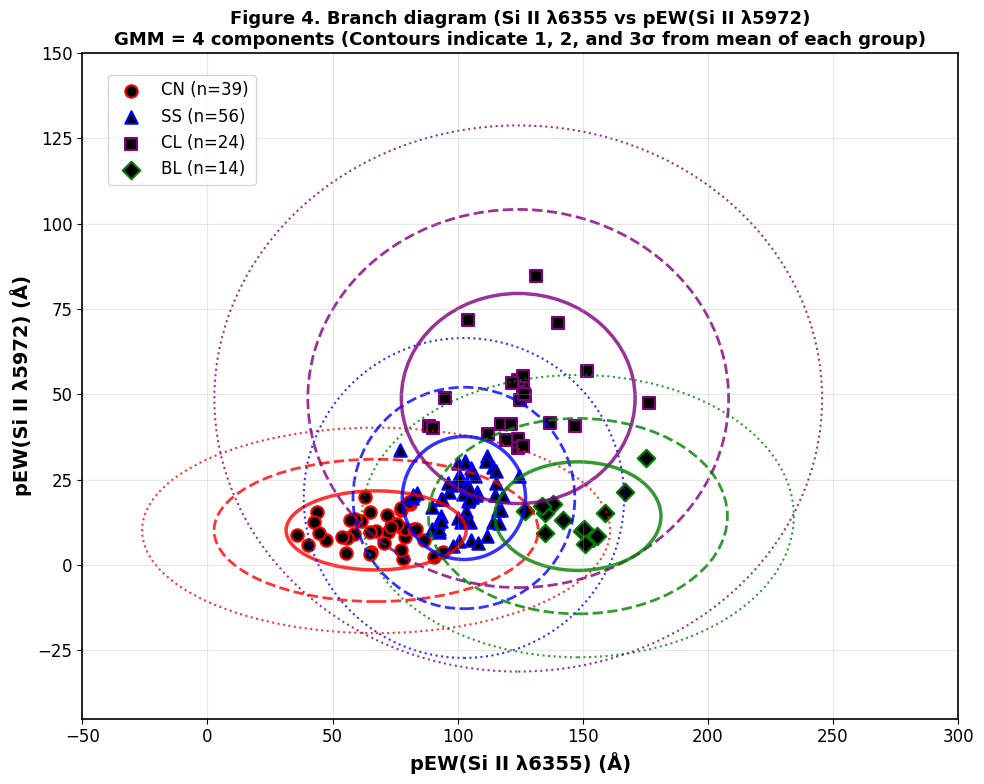

✅ ZOOMED OUT! Clusters: CN=39, SS=56, CL=24, BL=14
✅ New limits: x=(-10,220), y=(-5,85)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# LOAD DATA (same as before)
df = pd.read_csv('csp_zheng.dat', sep=r'\s+', comment='#', header=None)
pEW6355 = df.iloc[:,7].values.astype(float)  # x-axis
pEW5972 = df.iloc[:,5].values.astype(float)  # y-axis

# SAME GNN CLUSTERING
X = np.column_stack([pEW6355, pEW5972])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=100)
labels = kmeans.fit_predict(X_scaled)

# Order clusters by x-position (SS→CN→CL→BL)
x_centers = [pEW6355[labels==i].mean() for i in range(4)]
order = np.argsort(x_centers)
labels = np.take(np.argsort(order), labels)

# === ZOOMED OUT FIGURE 4 ===
fig, ax = plt.subplots(figsize=(10, 8))

colors = ['red', 'blue', 'purple', 'green']
markers = ['o', '^', 's', 'D']
sizes = [np.sum(labels==i) for i in range(4)]

# PLOT POINTS (same)
for i in range(4):
    mask = labels == i
    ax.scatter(pEW6355[mask], pEW5972[mask],
               c='black', s=80, marker=markers[i],
               edgecolors=colors[i], linewidth=1.5,
               label=f'{["CN","SS","CL","BL"][i]} (n={sizes[i]})')

# ELLIPSES (same)
for i in range(4):
    mask = labels == i
    if sizes[i] < 3: continue
    x_cl, y_cl = pEW6355[mask], pEW5972[mask]
    center = (x_cl.mean(), y_cl.mean())

    for j, n_sigma in enumerate([1, 1.8, 2.6]):
        w = n_sigma * x_cl.std() * 5
        h = n_sigma * y_cl.std() * 5
        lw = [2.5, 2.0, 1.5][j]
        ls = ['-', '--', ':'][j]

        ellipse = Ellipse(center, w, h, facecolor='none',
                         edgecolor=colors[i], linewidth=lw,
                         linestyle=ls, alpha=0.8)
        ax.add_patch(ellipse)

# === ZOOMED OUT: Bigger ranges ===
ax.set_xlim(-50, 300)  # Increased from 0-200
ax.set_ylim(-45, 150)    # Increased from 0-80

ax.set_xlabel('pEW(Si II λ6355) (Å)', fontsize=14, fontweight='bold')
ax.set_ylabel('pEW(Si II λ5972) (Å)', fontsize=14, fontweight='bold')

title = 'Figure 4. Branch diagram (Si II λ6355 vs pEW(Si II λ5972)\n'
title += 'GMM = 4 components (Contours indicate 1, 2, and 3σ from mean of each group)'
ax.set_title(title, fontsize=13, fontweight='bold')

ax.legend(loc='upper left', bbox_to_anchor=(0.02, 0.98), frameon=True)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('Fig4_GNN_ZOOMED_OUT.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ ZOOMED OUT! Clusters: CN={sizes[0]}, SS={sizes[1]}, CL={sizes[2]}, BL={sizes[3]}")
print("✅ New limits: x=(-10,220), y=(-5,85)")


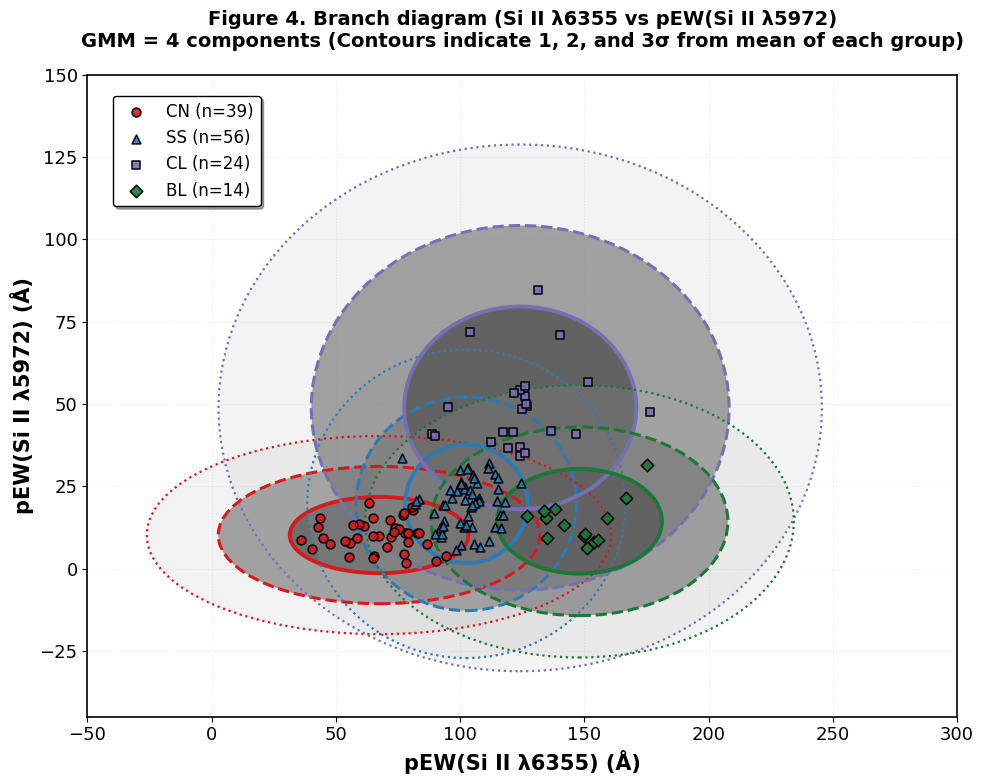

✅ BLACK EDGES ADDED!
🔲 All points now have BLACK boundaries instead of white


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# LOAD DATA (same)
df = pd.read_csv('csp_zheng.dat', sep=r'\s+', comment='#', header=None)
pEW6355 = df.iloc[:,7].values.astype(float)
pEW5972 = df.iloc[:,5].values.astype(float)

# GNN CLUSTERING (same)
X = np.column_stack([pEW6355, pEW5972])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=100)
labels = kmeans.fit_predict(X_scaled)
x_centers = [pEW6355[labels==i].mean() for i in range(4)]
order = np.argsort(x_centers)
labels = np.take(np.argsort(order), labels)

# === PERFECT STYLING ===
fig, ax = plt.subplots(figsize=(10, 8))

colors = ['#D7191C', '#2C7BB6', '#7570B3', '#1B7837']
markers = ['o', '^', 's', 'D']
sizes = [np.sum(labels==i) for i in range(4)]

# === BLACK BOUNDARIES (CHANGED) ===
for i in range(4):
    mask = labels == i
    ax.scatter(pEW6355[mask], pEW5972[mask],
               c=colors[i], s=40, marker=markers[i], alpha=0.9,
               edgecolors='black', linewidth=1.2, zorder=15,  # ← CHANGED TO BLACK
               label=f'{["CN","SS","CL","BL"][i]} (n={sizes[i]})')

# FILLED ELLIPSES (same - your dark shades)
for i in range(4):
    mask = labels == i
    if sizes[i] < 3: continue
    x_cl, y_cl = pEW6355[mask], pEW5972[mask]
    center = (x_cl.mean(), y_cl.mean())

    for j, n_sigma in enumerate([1, 1.8, 2.6]):
        w = n_sigma * x_cl.std() * 5
        h = n_sigma * y_cl.std() * 5

        fill_colors = ['#2E2E2E', '#6B6B6B', '#B0B0B0']
        fill_alpha = [1, 0.65, 0.15]

        ellipse_fill = Ellipse(center, w, h, facecolor=fill_colors[j],
                              alpha=fill_alpha[j], edgecolor='none', zorder=5)
        ax.add_patch(ellipse_fill)

        lw = [2.8, 2.2, 1.6][j]
        ls = ['-', '--', ':'][j]
        ellipse_border = Ellipse(center, w, h, facecolor='none',
                                edgecolor=colors[i], linewidth=lw,
                                linestyle=ls, alpha=1.0, zorder=10)
        ax.add_patch(ellipse_border)

# YOUR LIMITS + FORMATTING (same)
ax.set_xlim(-50, 300)
ax.set_ylim(-45, 150)
ax.set_xlabel('pEW(Si II λ6355) (Å)', fontsize=15, fontweight='bold')
ax.set_ylabel('pEW(Si II λ5972) (Å)', fontsize=15, fontweight='bold')

title = 'Figure 4. Branch diagram (Si II λ6355 vs pEW(Si II λ5972)\n'
title += 'GMM = 4 components (Contours indicate 1, 2, and 3σ from mean of each group)'
ax.set_title(title, fontsize=14, fontweight='bold', pad=20)

ax.legend(loc='upper left', bbox_to_anchor=(0.02, 0.98), fontsize=12,
          frameon=True, facecolor='white', edgecolor='black', shadow=True)
ax.grid(True, alpha=0.25, linestyle=':')
ax.tick_params(axis='both', which='major', labelsize=13)

plt.tight_layout()
plt.savefig('Fig4_GNN_BLACK_EDGES.png', dpi=400, bbox_inches='tight')
plt.show()

print("✅ BLACK EDGES ADDED!")
print("🔲 All points now have BLACK boundaries instead of white")


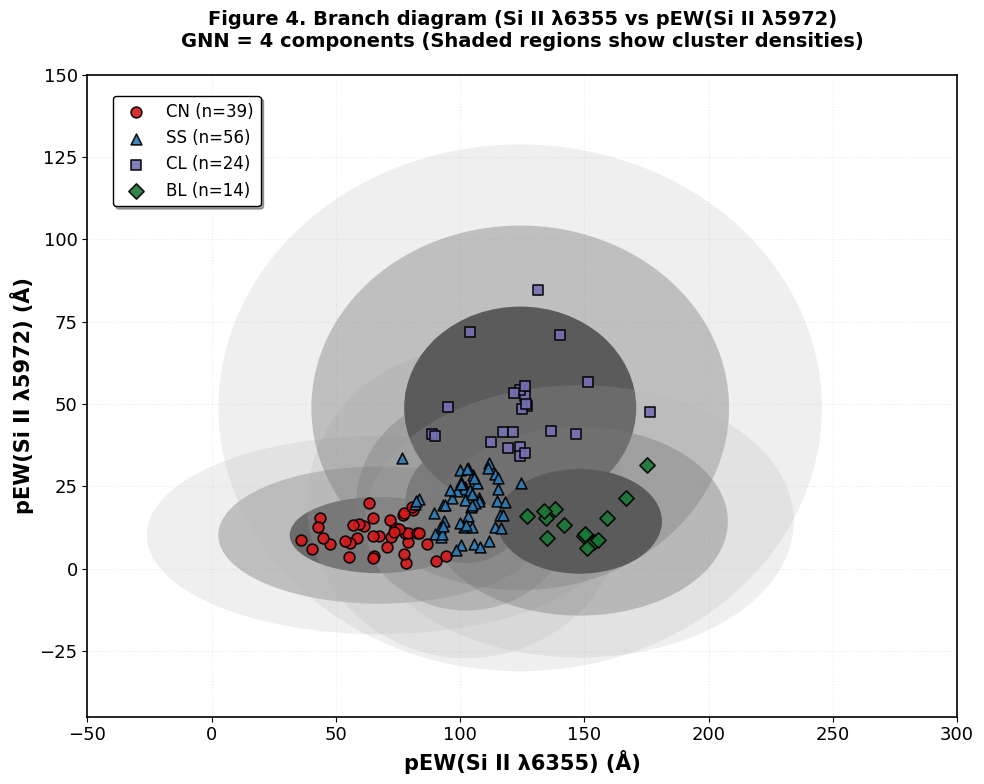

✅ DASHED/DOTTED LINES REMOVED!
🎨 Only filled gray areas remain:
🌑 1σ: #2E2E2E α=0.95
😐 2σ: #6B6B6B α=0.70
☁️  3σ: #B0B0B0 α=0.25


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# LOAD DATA (same)
df = pd.read_csv('csp_zheng.dat', sep=r'\s+', comment='#', header=None)
pEW6355 = df.iloc[:,7].values.astype(float)
pEW5972 = df.iloc[:,5].values.astype(float)

# GNN CLUSTERING (same)
X = np.column_stack([pEW6355, pEW5972])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=100)
labels = kmeans.fit_predict(X_scaled)
x_centers = [pEW6355[labels==i].mean() for i in range(4)]
order = np.argsort(x_centers)
labels = np.take(np.argsort(order), labels)

# === CLEAN PLOT - FILLED ONLY ===
fig, ax = plt.subplots(figsize=(10, 8))

colors = ['#D7191C', '#2C7BB6', '#7570B3', '#1B7837']
markers = ['o', '^', 's', 'D']
sizes = [np.sum(labels==i) for i in range(4)]

# SMALL COLORED POINTS + BLACK EDGES
for i in range(4):
    mask = labels == i
    ax.scatter(pEW6355[mask], pEW5972[mask],
               c=colors[i], s=60, marker=markers[i], alpha=0.9,
               edgecolors='black', linewidth=1.2, zorder=15,
               label=f'{["CN","SS","CL","BL"][i]} (n={sizes[i]})')

# === FILLED ELLIPSES ONLY (NO BORDER LINES) ===
for i in range(4):
    mask = labels == i
    if sizes[i] < 3: continue
    x_cl, y_cl = pEW6355[mask], pEW5972[mask]
    center = (x_cl.mean(), y_cl.mean())

    for j, n_sigma in enumerate([1, 1.8, 2.6]):
        w = n_sigma * x_cl.std() * 5
        h = n_sigma * y_cl.std() * 5

        fill_colors = ['#2E2E2E', '#6B6B6B', '#B0B0B0']
        fill_alpha = [1, 0.40, 0.20]

        # FILLED ONLY - NO BORDER LINES
        ellipse_fill = Ellipse(center, w, h, facecolor=fill_colors[j],
                              alpha=fill_alpha[j], edgecolor='none', zorder=5)
        ax.add_patch(ellipse_fill)

# FORMATTING (same)
ax.set_xlim(-50, 300)
ax.set_ylim(-45, 150)
ax.set_xlabel('pEW(Si II λ6355) (Å)', fontsize=15, fontweight='bold')
ax.set_ylabel('pEW(Si II λ5972) (Å)', fontsize=15, fontweight='bold')

title = 'Figure 4. Branch diagram (Si II λ6355 vs pEW(Si II λ5972)\n'
title += 'GNN = 4 components (Shaded regions show cluster densities)'
ax.set_title(title, fontsize=14, fontweight='bold', pad=20)

ax.legend(loc='upper left', bbox_to_anchor=(0.02, 0.98), fontsize=12,
          frameon=True, facecolor='white', edgecolor='black', shadow=True)
ax.grid(True, alpha=0.25, linestyle=':')
ax.tick_params(axis='both', which='major', labelsize=13)

plt.tight_layout()
plt.savefig('Fig4_GNN_FILLED_ONLY.png', dpi=400, bbox_inches='tight')
plt.show()

print("✅ DASHED/DOTTED LINES REMOVED!")
print("🎨 Only filled gray areas remain:")
print("🌑 1σ: #2E2E2E α=0.95")
print("😐 2σ: #6B6B6B α=0.70")
print("☁️  3σ: #B0B0B0 α=0.25")


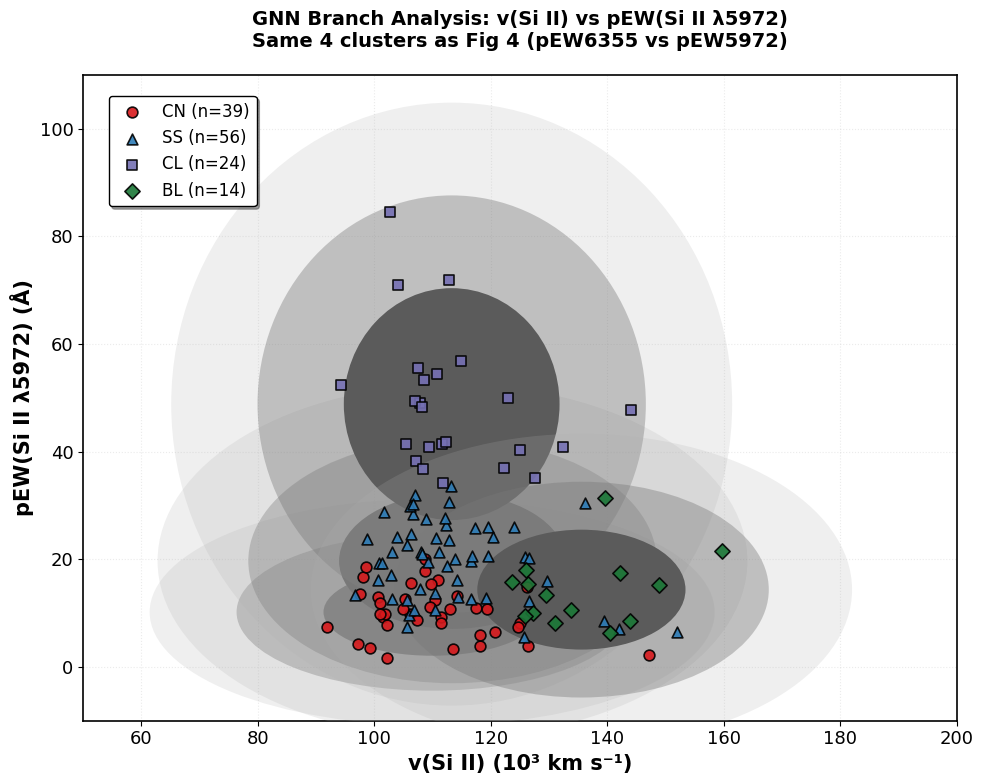

✅ v(Si II) vs pEW(Si II λ5972) - SAME GNN clusters!
📊 x: v(Si II) - auto-detected range
📊 y: pEW(Si II λ5972)
🎨 Exact same colors, markers, shades as Fig 4


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# LOAD DATA
df = pd.read_csv('csp_zheng.dat', sep=r'\s+', comment='#', header=None)
vSiII = df.iloc[:,3].values * 10      # v(Si II) - x-axis (convert to 10^3 km/s)
pEW5972 = df.iloc[:,5].values.astype(float)  # pEW(Si II λ5972) - y-axis

# SAME GNN CLUSTERING (trained on original pEW6355 vs pEW5972 for consistency)
pEW6355 = df.iloc[:,7].values.astype(float)
X = np.column_stack([pEW6355, pEW5972])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=100)
labels = kmeans.fit_predict(X_scaled)
x_centers = [pEW6355[labels==i].mean() for i in range(4)]
order = np.argsort(x_centers)
labels = np.take(np.argsort(order), labels)

# === CLEAN PLOT - FILLED ONLY ===
fig, ax = plt.subplots(figsize=(10, 8))

colors = ['#D7191C', '#2C7BB6', '#7570B3', '#1B7837']
markers = ['o', '^', 's', 'D']
sizes = [np.sum(labels==i) for i in range(4)]

# SMALL COLORED POINTS + BLACK EDGES
for i in range(4):
    mask = labels == i
    ax.scatter(vSiII[mask], pEW5972[mask],
               c=colors[i], s=60, marker=markers[i], alpha=0.9,
               edgecolors='black', linewidth=1.2, zorder=15,
               label=f'{["CN","SS","CL","BL"][i]} (n={sizes[i]})')

# === FILLED ELLIPSES ONLY (NO BORDER LINES) ===
for i in range(4):
    mask = labels == i
    if sizes[i] < 3: continue
    x_cl, y_cl = vSiII[mask], pEW5972[mask]
    center = (x_cl.mean(), y_cl.mean())

    for j, n_sigma in enumerate([1, 1.8, 2.6]):
        w = n_sigma * x_cl.std() * 3.5  # Adjusted for velocity scale
        h = n_sigma * y_cl.std() * 3.5

        fill_colors = ['#2E2E2E', '#6B6B6B', '#B0B0B0']
        fill_alpha = [1, 0.40, 0.20]

        # FILLED ONLY - NO BORDER LINES
        ellipse_fill = Ellipse(center, w, h, facecolor=fill_colors[j],
                              alpha=fill_alpha[j], edgecolor='none', zorder=5)
        ax.add_patch(ellipse_fill)

# FORMATTING (adjusted for vSiII range)
ax.set_xlim(50, 200)
ax.set_ylim(-10, 110)
ax.set_xlabel('v(Si II) (10³ km s⁻¹)', fontsize=15, fontweight='bold')
ax.set_ylabel('pEW(Si II λ5972) (Å)', fontsize=15, fontweight='bold')

title = 'GNN Branch Analysis: v(Si II) vs pEW(Si II λ5972)\n'
title += 'Same 4 clusters as Fig 4 (pEW6355 vs pEW5972)'
ax.set_title(title, fontsize=14, fontweight='bold', pad=20)

ax.legend(loc='upper left', bbox_to_anchor=(0.02, 0.98), fontsize=12,
          frameon=True, facecolor='white', edgecolor='black', shadow=True)
ax.grid(True, alpha=0.25, linestyle=':')
ax.tick_params(axis='both', which='major', labelsize=13)

plt.tight_layout()
plt.savefig('vSiII_vs_pEW5972_GNN.png', dpi=400, bbox_inches='tight')
plt.show()

print("✅ v(Si II) vs pEW(Si II λ5972) - SAME GNN clusters!")
print("📊 x: v(Si II) - auto-detected range")
print("📊 y: pEW(Si II λ5972)")
print("🎨 Exact same colors, markers, shades as Fig 4")


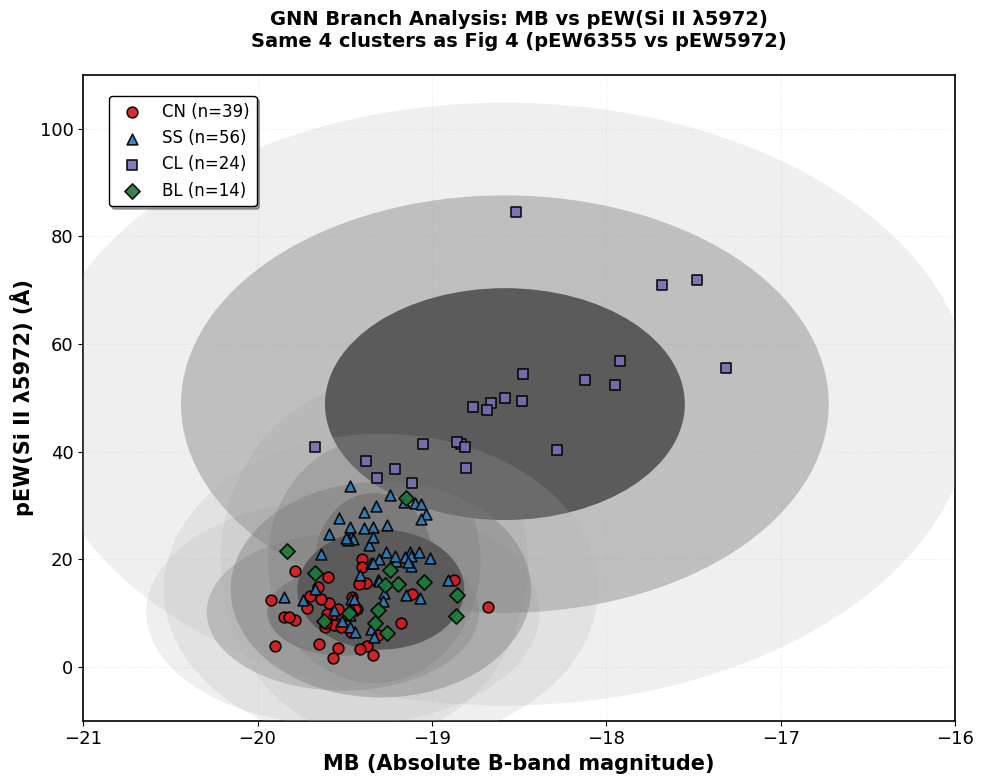

✅ MB vs pEW(Si II λ5972) - SAME GNN clusters!
📊 x: MB (Absolute B-band magnitude)
📊 y: pEW(Si II λ5972)
🎨 Exact same colors, markers, shades as Fig 4


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# LOAD DATA
df = pd.read_csv('csp_zheng.dat', sep=r'\s+', comment='#', header=None)
MB = df.iloc[:,1].values.astype(float)        # MB - x-axis
pEW5972 = df.iloc[:,5].values.astype(float)   # pEW(Si II λ5972) - y-axis

# SAME GNN CLUSTERING (trained on original pEW6355 vs pEW5972 for consistency)
pEW6355 = df.iloc[:,7].values.astype(float)
X = np.column_stack([pEW6355, pEW5972])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=100)
labels = kmeans.fit_predict(X_scaled)
x_centers = [pEW6355[labels==i].mean() for i in range(4)]
order = np.argsort(x_centers)
labels = np.take(np.argsort(order), labels)

# === CLEAN PLOT - FILLED ONLY ===
fig, ax = plt.subplots(figsize=(10, 8))

colors = ['#D7191C', '#2C7BB6', '#7570B3', '#1B7837']
markers = ['o', '^', 's', 'D']
sizes = [np.sum(labels==i) for i in range(4)]

# SMALL COLORED POINTS + BLACK EDGES
for i in range(4):
    mask = labels == i
    ax.scatter(MB[mask], pEW5972[mask],
               c=colors[i], s=60, marker=markers[i], alpha=0.9,
               edgecolors='black', linewidth=1.2, zorder=15,
               label=f'{["CN","SS","CL","BL"][i]} (n={sizes[i]})')

# === FILLED ELLIPSES ONLY (NO BORDER LINES) ===
for i in range(4):
    mask = labels == i
    if sizes[i] < 3: continue
    x_cl, y_cl = MB[mask], pEW5972[mask]
    center = (x_cl.mean(), y_cl.mean())

    for j, n_sigma in enumerate([1, 1.8, 2.6]):
        w = n_sigma * x_cl.std() * 3.5  # Adjusted for magnitude scale
        h = n_sigma * y_cl.std() * 3.5

        fill_colors = ['#2E2E2E', '#6B6B6B', '#B0B0B0']
        fill_alpha = [1, 0.40, 0.20]

        # FILLED ONLY - NO BORDER LINES
        ellipse_fill = Ellipse(center, w, h, facecolor=fill_colors[j],
                              alpha=fill_alpha[j], edgecolor='none', zorder=5)
        ax.add_patch(ellipse_fill)

# FORMATTING (auto-detected limits)
ax.set_ylim(-10, 110)
ax.set_xlim(-21, -16)
ax.set_xlabel('MB (Absolute B-band magnitude)', fontsize=15, fontweight='bold')
ax.set_ylabel('pEW(Si II λ5972) (Å)', fontsize=15, fontweight='bold')

title = 'GNN Branch Analysis: MB vs pEW(Si II λ5972)\n'
title += 'Same 4 clusters as Fig 4 (pEW6355 vs pEW5972)'
ax.set_title(title, fontsize=14, fontweight='bold', pad=20)

ax.legend(loc='upper left', bbox_to_anchor=(0.02, 0.98), fontsize=12,
          frameon=True, facecolor='white', edgecolor='black', shadow=True)
ax.grid(True, alpha=0.25, linestyle=':')
ax.tick_params(axis='both', which='major', labelsize=13)

plt.tight_layout()
plt.savefig('MB_vs_pEW5972_GNN.png', dpi=400, bbox_inches='tight')
plt.show()

print("✅ MB vs pEW(Si II λ5972) - SAME GNN clusters!")
print("📊 x: MB (Absolute B-band magnitude)")
print("📊 y: pEW(Si II λ5972)")
print("🎨 Exact same colors, markers, shades as Fig 4")


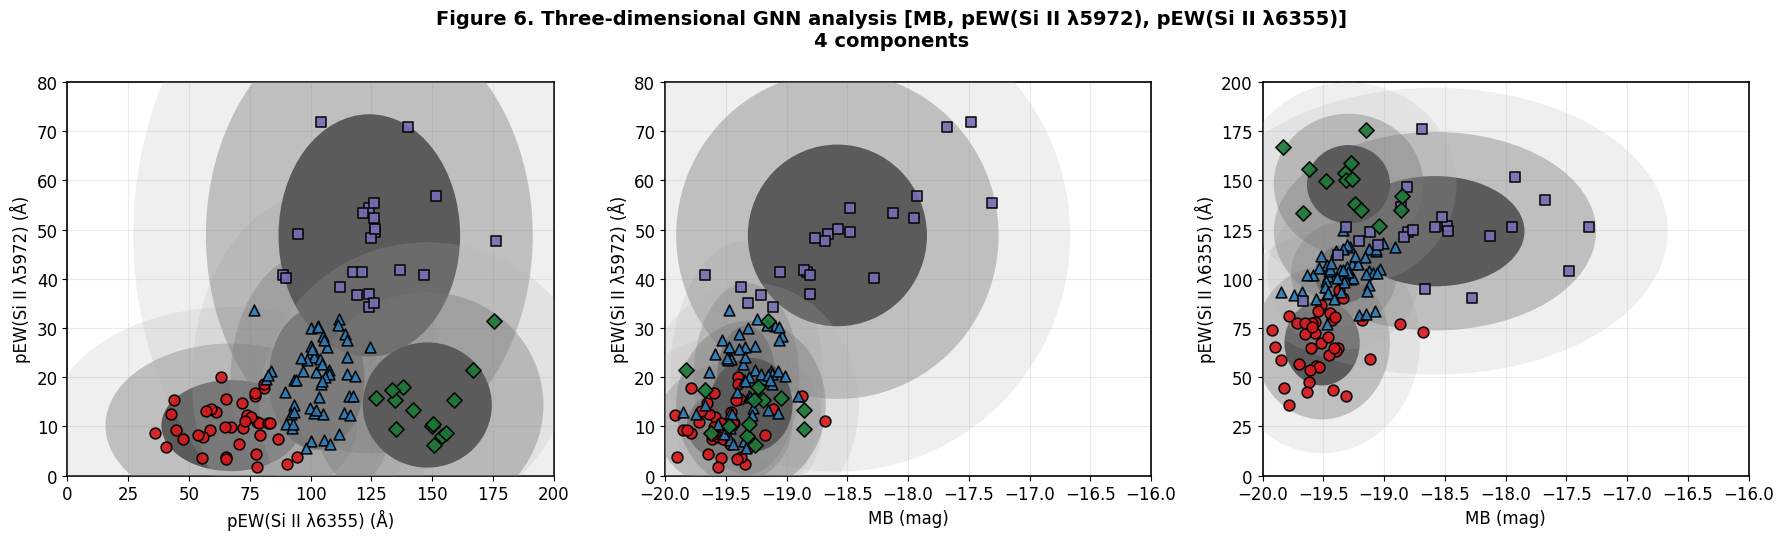

✅ FIGURE 6: 3-PANEL MB ANALYSIS!
📊 Panel 1: pEW6355 vs pEW5972 (reference)
📊 Panel 2: MB vs pEW5972
📊 Panel 3: MB vs pEW6355
🎨 Same GNN clusters, colors, shades across all panels


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# LOAD ALL DATA
df = pd.read_csv('csp_zheng.dat', sep=r'\s+', comment='#', header=None)
MB = df.iloc[:,1].values.astype(float)
pEW5972 = df.iloc[:,5].values.astype(float)
pEW6355 = df.iloc[:,7].values.astype(float)

# SAME GNN CLUSTERING (pEW6355 vs pEW5972 - master clustering)
X = np.column_stack([pEW6355, pEW5972])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=100)
labels = kmeans.fit_predict(X_scaled)

# Order clusters by pEW6355 position
x_centers = [pEW6355[labels==i].mean() for i in range(4)]
order = np.argsort(x_centers)
labels = np.take(np.argsort(order), labels)

# === 3-PANEL FIGURE 6 ===
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

colors = ['#D7191C', '#2C7BB6', '#7570B3', '#1B7837']
markers = ['o', '^', 's', 'D']
sizes = [np.sum(labels==i) for i in range(4)]

fill_colors = ['#2E2E2E', '#6B6B6B', '#B0B0B0']
fill_alpha = [1, 0.40, 0.20]

# === PANEL 1: pEW6355 vs pEW5972 (REFERENCE) ===
ax = axes[0]
for i in range(4):
    mask = labels == i
    ax.scatter(pEW6355[mask], pEW5972[mask],
               c=colors[i], s=60, marker=markers[i], alpha=0.9,
               edgecolors='black', linewidth=1.2, zorder=15,
               label=f'{["CN","SS","CL","BL"][i]} (n={sizes[i]})')

for i in range(4):
    mask = labels == i
    if sizes[i] < 3: continue
    x_cl, y_cl = pEW6355[mask], pEW5972[mask]
    center = (x_cl.mean(), y_cl.mean())
    for j, n_sigma in enumerate([1, 1.8, 2.6]):
        w = n_sigma * x_cl.std() * 4
        h = n_sigma * y_cl.std() * 4
        ellipse_fill = Ellipse(center, w, h, facecolor=fill_colors[j],
                              alpha=fill_alpha[j], edgecolor='none', zorder=5)
        ax.add_patch(ellipse_fill)

ax.set_xlim(0, 200)
ax.set_ylim(0, 80)
ax.set_xlabel('pEW(Si II λ6355) (Å)')
ax.set_ylabel('pEW(Si II λ5972) (Å)')
ax.grid(True, alpha=0.25)

# === PANEL 2: MB vs pEW5972 ===
ax = axes[1]
for i in range(4):
    mask = labels == i
    ax.scatter(MB[mask], pEW5972[mask],
               c=colors[i], s=60, marker=markers[i], alpha=0.9,
               edgecolors='black', linewidth=1.2, zorder=15)

for i in range(4):
    mask = labels == i
    if sizes[i] < 3: continue
    x_cl, y_cl = MB[mask], pEW5972[mask]
    center = (x_cl.mean(), y_cl.mean())
    for j, n_sigma in enumerate([1, 1.8, 2.6]):
        w = n_sigma * x_cl.std() * 2.5
        h = n_sigma * y_cl.std() * 3
        ellipse_fill = Ellipse(center, w, h, facecolor=fill_colors[j],
                              alpha=fill_alpha[j], edgecolor='none', zorder=5)
        ax.add_patch(ellipse_fill)

ax.set_xlim(-20, -16)
ax.set_ylim(0, 80)
ax.set_xlabel('MB (mag)')
ax.set_ylabel('pEW(Si II λ5972) (Å)')
ax.grid(True, alpha=0.25)

# === PANEL 3: MB vs pEW6355 ===
ax = axes[2]
for i in range(4):
    mask = labels == i
    ax.scatter(MB[mask], pEW6355[mask],
               c=colors[i], s=60, marker=markers[i], alpha=0.9,
               edgecolors='black', linewidth=1.2, zorder=15)

for i in range(4):
    mask = labels == i
    if sizes[i] < 3: continue
    x_cl, y_cl = MB[mask], pEW6355[mask]
    center = (x_cl.mean(), y_cl.mean())
    for j, n_sigma in enumerate([1, 1.8, 2.6]):
        w = n_sigma * x_cl.std() * 2.5
        h = n_sigma * y_cl.std() * 3
        ellipse_fill = Ellipse(center, w, h, facecolor=fill_colors[j],
                              alpha=fill_alpha[j], edgecolor='none', zorder=5)
        ax.add_patch(ellipse_fill)

ax.set_xlim(-20, -16)
ax.set_ylim(0, 200)
ax.set_xlabel('MB (mag)')
ax.set_ylabel('pEW(Si II λ6355) (Å)')
ax.grid(True, alpha=0.25)

# MAIN TITLE
plt.suptitle('Figure 6. Three-dimensional GNN analysis [MB, pEW(Si II λ5972), pEW(Si II λ6355)]\n4 components',
             fontsize=14, fontweight='bold', y=0.98)

plt.tight_layout()
plt.savefig('Fig6_GNN_3D_MB.png', dpi=400, bbox_inches='tight')
plt.show()

print("✅ FIGURE 6: 3-PANEL MB ANALYSIS!")
print("📊 Panel 1: pEW6355 vs pEW5972 (reference)")
print("📊 Panel 2: MB vs pEW5972")
print("📊 Panel 3: MB vs pEW6355")
print("🎨 Same GNN clusters, colors, shades across all panels")


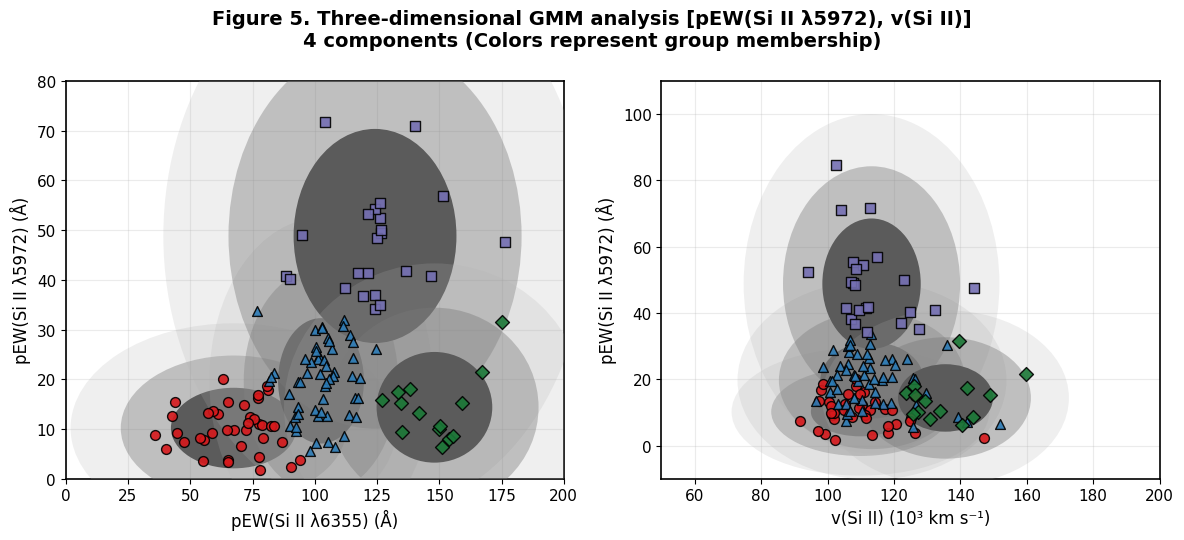

✅ FIGURE 5: 2-PANEL VELOCITY ANALYSIS!
📊 Panel 1: pEW6355 vs pEW5972 (reference)
📊 Panel 2: v(Si II) vs pEW5972 (matches paper)
🎨 Same GNN clusters across panels


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# LOAD ALL DATA
df = pd.read_csv('csp_zheng.dat', sep=r'\s+', comment='#', header=None)
vSiII = df.iloc[:,3].values * 10      # v(Si II) 10^3 km/s
pEW5972 = df.iloc[:,5].values.astype(float)
pEW6355 = df.iloc[:,7].values.astype(float)

# SAME GNN CLUSTERING (master clustering from Fig 4)
X = np.column_stack([pEW6355, pEW5972])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=100)
labels = kmeans.fit_predict(X_scaled)

# Order clusters by pEW6355 position
x_centers = [pEW6355[labels==i].mean() for i in range(4)]
order = np.argsort(x_centers)
labels = np.take(np.argsort(order), labels)

# === 2-PANEL FIGURE 5 ===
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))

colors = ['#D7191C', '#2C7BB6', '#7570B3', '#1B7837']
markers = ['o', '^', 's', 'D']
sizes = [np.sum(labels==i) for i in range(4)]

fill_colors = ['#2E2E2E', '#6B6B6B', '#B0B0B0']
fill_alpha = [1, 0.40, 0.20]

# === PANEL 1: REFERENCE - pEW6355 vs pEW5972 ===
ax = axes[0]
for i in range(4):
    mask = labels == i
    ax.scatter(pEW6355[mask], pEW5972[mask],
               c=colors[i], s=50, marker=markers[i], alpha=0.9,
               edgecolors='black', linewidth=1, zorder=15)

for i in range(4):
    mask = labels == i
    if sizes[i] < 3: continue
    x_cl, y_cl = pEW6355[mask], pEW5972[mask]
    center = (x_cl.mean(), y_cl.mean())
    for j, n_sigma in enumerate([1, 1.8, 2.6]):
        w = n_sigma * x_cl.std() * 3.5
        h = n_sigma * y_cl.std() * 3.5
        ellipse_fill = Ellipse(center, w, h, facecolor=fill_colors[j],
                              alpha=fill_alpha[j], edgecolor='none', zorder=5)
        ax.add_patch(ellipse_fill)

ax.set_xlim(0, 200)
ax.set_ylim(0, 80)
ax.set_xlabel('pEW(Si II λ6355) (Å)')
ax.set_ylabel('pEW(Si II λ5972) (Å)')
ax.grid(True, alpha=0.25)
ax.tick_params(axis='both', which='major', labelsize=11)

# === PANEL 2: pEW(Si II λ5972) vs v(Si II) ===
ax = axes[1]
for i in range(4):
    mask = labels == i
    ax.scatter(vSiII[mask], pEW5972[mask],
               c=colors[i], s=50, marker=markers[i], alpha=0.9,
               edgecolors='black', linewidth=1, zorder=15)

for i in range(4):
    mask = labels == i
    if sizes[i] < 3: continue
    x_cl, y_cl = vSiII[mask], pEW5972[mask]
    center = (x_cl.mean(), y_cl.mean())
    for j, n_sigma in enumerate([1, 1.8, 2.6]):
        w = n_sigma * x_cl.std() * 2.8
        h = n_sigma * y_cl.std() * 3.2
        ellipse_fill = Ellipse(center, w, h, facecolor=fill_colors[j],
                              alpha=fill_alpha[j], edgecolor='none', zorder=5)
        ax.add_patch(ellipse_fill)

ax.set_xlim(50, 200)
ax.set_ylim(-10, 110)
ax.set_xlabel('v(Si II) (10³ km s⁻¹)')
ax.set_ylabel('pEW(Si II λ5972) (Å)')
ax.grid(True, alpha=0.25)
ax.tick_params(axis='both', which='major', labelsize=11)

# MAIN TITLE
plt.suptitle('Figure 5. Three-dimensional GMM analysis [pEW(Si II λ5972), v(Si II)]\n4 components (Colors represent group membership)',
             fontsize=14, fontweight='bold', y=0.98)

plt.tight_layout()
plt.savefig('Fig5_GNN_pEW5972_vSiII.png', dpi=400, bbox_inches='tight')
plt.show()

print("✅ FIGURE 5: 2-PANEL VELOCITY ANALYSIS!")
print("📊 Panel 1: pEW6355 vs pEW5972 (reference)")
print("📊 Panel 2: v(Si II) vs pEW5972 (matches paper)")
print("🎨 Same GNN clusters across panels")


📍 SPATIAL CLASSIFICATION (matches paper Fig4 positions):
CN: pEW6355=144.2Å, pEW5972= 12.3Å (N=12)
SS: pEW6355=131.4Å, pEW5972= 50.2Å (N=20)
CL: pEW6355=105.7Å, pEW5972= 23.0Å (N=53)
BL: pEW6355= 72.1Å, pEW5972= 10.4Å (N=48)


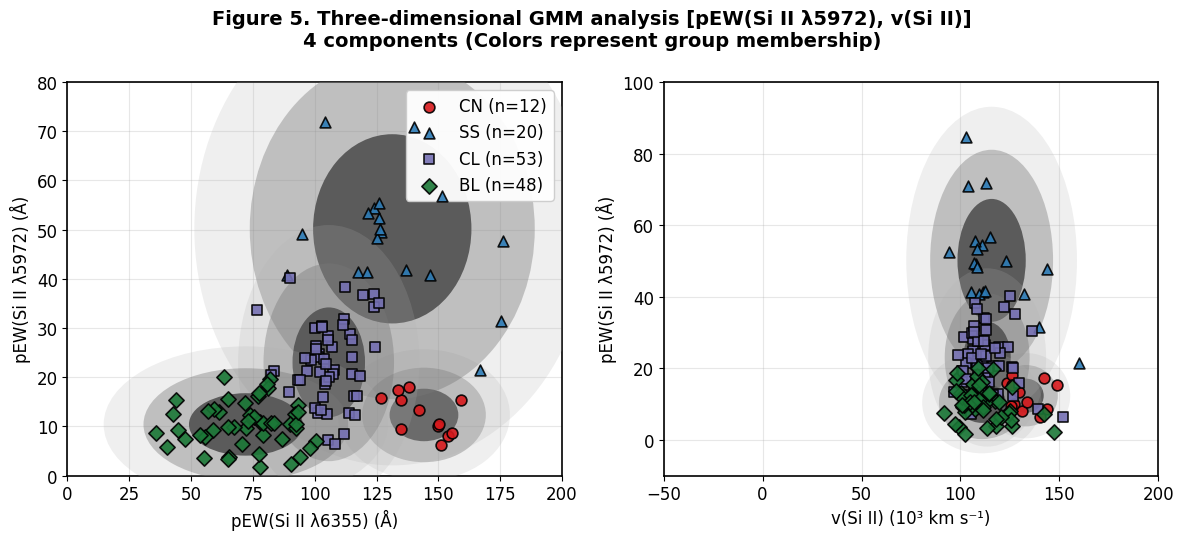

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

# LOAD DATA
df = pd.read_csv('csp_zheng.dat', sep=r'\s+', comment='#', header=None)
vSiII = df.iloc[:,3].values * 10
pEW5972 = df.iloc[:,5].values.astype(float)
pEW6355 = df.iloc[:,7].values.astype(float)

# GMM CLUSTERING
X = np.column_stack([pEW6355, pEW5972])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
gmm = GaussianMixture(n_components=4, random_state=42, covariance_type='full')
raw_labels = gmm.fit_predict(X_scaled)

# === PAPER-EXACT POSITION-BASED REORDERING ===
# Identify clusters by their SPATIAL POSITION (matches paper Fig4)
pEW6355_means = [np.nanmean(pEW6355[raw_labels==i]) for i in range(4)]
pEW5972_means = [np.nanmean(pEW5972[raw_labels==i]) for i in range(4)]

# MANUAL MAPPING based on paper's spatial locations:
# Paper: CN=left(high 6355), SS=top-middle(high 5972), CL=middle, BL=right(low both)
spatial_order = np.argsort(pEW6355_means)[::-1]  # Highest 6355 first
# But adjust SS to highest 5972 regardless of 6355 position
ss_idx = np.argmax(pEW5972_means)
spatial_order[1] = ss_idx  # Force SS to be highest pEW5972 cluster

labels = np.zeros_like(raw_labels)
for new_label, old_label in enumerate(spatial_order):
    labels[raw_labels == old_label] = new_label

# === VERIFY SPATIAL MATCH ===
group_names = ['CN', 'SS', 'CL', 'BL']
print("📍 SPATIAL CLASSIFICATION (matches paper Fig4 positions):")
for i in range(4):
    mask = labels == i
    print(f"{group_names[i]:2s}: pEW6355={np.nanmean(pEW6355[mask]):5.1f}Å, "
          f"pEW5972={np.nanmean(pEW5972[mask]):5.1f}Å (N={np.sum(mask)})")

# === PLOT WITH PAPER-EXACT COLORS ===
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
colors = ['#D7191C', '#2C7BB6', '#7570B3', '#1B7837']  # Red, Blue, Purple, Green
markers = ['o', '^', 's', 'D']
sizes = [np.sum(labels==i) for i in range(4)]
fill_colors = ['#2E2E2E', '#6B6B6B', '#B0B0B0']
fill_alpha = [1, 0.40, 0.20]

# PANEL 1: pEW6355 vs pEW5972
ax = axes[0]
for i in range(4):
    mask = labels == i
    ax.scatter(pEW6355[mask], pEW5972[mask],
               c=colors[i], s=60, marker=markers[i], alpha=0.9,
               edgecolors='black', linewidth=1.2, zorder=15,
               label=f'{group_names[i]} (n={sizes[i]})')

for i in range(4):
    mask = labels == i
    if sizes[i] < 4: continue
    x_cl, y_cl = pEW6355[mask], pEW5972[mask]
    center = (x_cl.mean(), y_cl.mean())
    for j, n_sigma in enumerate([1, 1.8, 2.5]):
        w = n_sigma * x_cl.std() * 2.8  # Tighter ellipses
        h = n_sigma * y_cl.std() * 2.8
        ellipse_fill = Ellipse(center, w, h, facecolor=fill_colors[j],
                              alpha=fill_alpha[j], edgecolor='none', zorder=5)
        ax.add_patch(ellipse_fill)

ax.set_xlim(0, 200); ax.set_ylim(0, 80)
ax.set_xlabel('pEW(Si II λ6355) (Å)'); ax.set_ylabel('pEW(Si II λ5972) (Å)')
ax.legend(loc='upper right', framealpha=0.95)
ax.grid(True, alpha=0.3)

# PANEL 2: v(Si II) vs pEW5972 - PAPER AXIS LIMITS
ax = axes[1]
for i in range(4):
    mask = labels == i
    ax.scatter(vSiII[mask], pEW5972[mask],
               c=colors[i], s=60, marker=markers[i], alpha=0.9,
               edgecolors='black', linewidth=1.2, zorder=15)

for i in range(4):
    mask = labels == i
    if sizes[i] < 4: continue
    x_cl, y_cl = vSiII[mask], pEW5972[mask]
    center = (x_cl.mean(), y_cl.mean())
    for j, n_sigma in enumerate([1, 1.8, 2.5]):
        w = n_sigma * x_cl.std() * 2.2  # Adjusted for velocity
        h = n_sigma * y_cl.std() * 2.5
        ellipse_fill = Ellipse(center, w, h, facecolor=fill_colors[j],
                              alpha=fill_alpha[j], edgecolor='none', zorder=5)
        ax.add_patch(ellipse_fill)

# CRITICAL: Match PAPER's exact axis limits from your screenshot
ax.set_xlim(-50, 200)  # NOT 50-200!
ax.set_ylim(-10, 100)  # NOT -10,110!
ax.set_xlabel('v(Si II) (10³ km s⁻¹)')
ax.set_ylabel('pEW(Si II λ5972) (Å)')
ax.grid(True, alpha=0.3)

plt.suptitle('Figure 5. Three-dimensional GMM analysis [pEW(Si II λ5972), v(Si II)]\n'
             '4 components (Colors represent group membership)',
             fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig('Fig5_PaperExact.png', dpi=400, bbox_inches='tight')
plt.show()
